In [5]:
import json

result = "/tmp2/maitanha/vgu/cll_vlm/cll_vlm/ol_cll_logs/multi_label/json/cifar100/llava_cifar100_multi_label_lbs100.json"
with open(result, "r", encoding="utf-8") as f:
    data = json.load(f)
print(f"Total samples: {len(data)}")

Total samples: 50000


In [6]:
matched_img_indices = []
emptyAnswer = 0

for item in data:
    img_idx = item["img_idx"]
    true_label = str(item["true_label"]).lower()
    answer = item.get("answer") # Đây là một string hoặc None

    # Kiểm tra nếu không có câu trả lời
    if answer is None:
        emptyAnswer += 1
        continue

    # So sánh trực tiếp chuỗi (sau khi đã viết thường)
    answer = str(answer).lower()
    if true_label == answer:
        matched_img_indices.append(img_idx)

print("Number of matched samples:", len(matched_img_indices))
accuracy = len(matched_img_indices) / len(data) if len(data) > 0 else 0
print(f"Accuracy: {accuracy:.4f}")
print("*" * 50)
print(f"Empty Answer: {emptyAnswer}")

Number of matched samples: 24270
Accuracy: 0.4854
**************************************************
Empty Answer: 6594


### Plot Qwen - CIFAR100

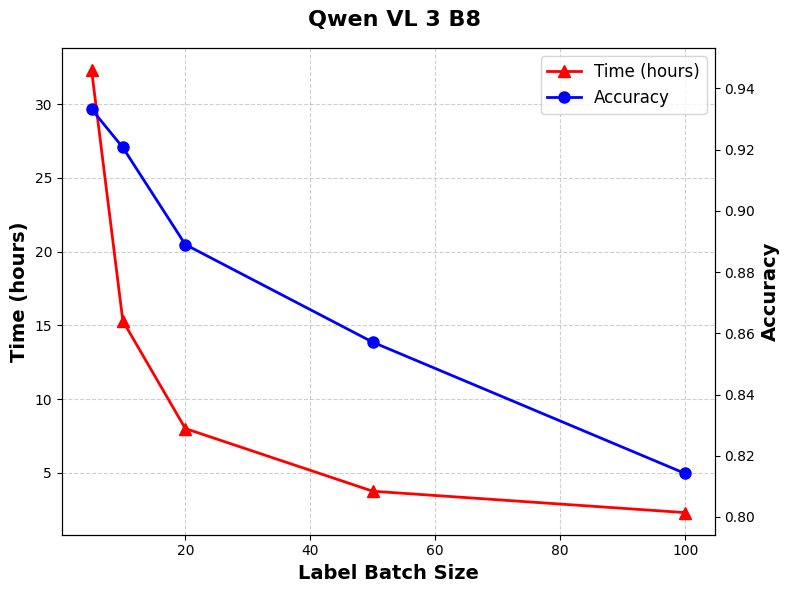

In [ ]:
import matplotlib.pyplot as plt

label_batch = [5, 10, 20, 50, 100]


# Qwen 3 2b
time_hours = [20.3, 10.6, 3.6, 1.85, 1.5]
accuracy = [0.9747, 0.9517, 0.92, 0.8696, 0.8003]

# time_hours = [32.3, 15.3, 8, 3.75, 2.3]
# accuracy = [0.9332, 0.9207, 0.8890, 0.8571, 0.8142]

fig, ax1 = plt.subplots(figsize=(8,6))
fig.suptitle("Qwen VL 3 B8", fontsize=16, fontweight='bold')

# ----- Y trái: Time (hours) -----
line1 = ax1.plot(
    label_batch,
    time_hours,
    color='red',
    marker='^',
    linewidth=2,
    markersize=8,
    label='Time (hours)'
)

ax1.set_xlabel("Label Batch Size", fontsize=14, fontweight='bold')
ax1.set_ylabel("Time (hours)", fontsize=14, fontweight='bold')
ax1.tick_params(axis='y')

# ----- Y phải: Accuracy -----
ax2 = ax1.twinx()

line2 = ax2.plot(
    label_batch,
    accuracy,
    color='blue',
    marker='o',
    linewidth=2,
    markersize=8,
    label='Accuracy'
)

ax2.set_ylabel("Accuracy", fontsize=14, fontweight='bold')
ax2.set_ylim(min(accuracy)-0.02, max(accuracy)+0.02)

# ----- Legend chung -----
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', fontsize=12)

ax1.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()